In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetes.csv')

In [10]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [34]:
df1_copy.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [35]:
df1_copy.shape

(768, 9)

In [36]:
df1_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
df1_copy.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [38]:
df1_copy["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [39]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df1_copy[cols] = df1_copy[cols].replace(0, np.nan)

NameError: name 'np' is not defined

In [40]:
df1_copy.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [42]:
df1_copy.fillna(df1_copy.median(), inplace=True)

In [43]:
df1_copy.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

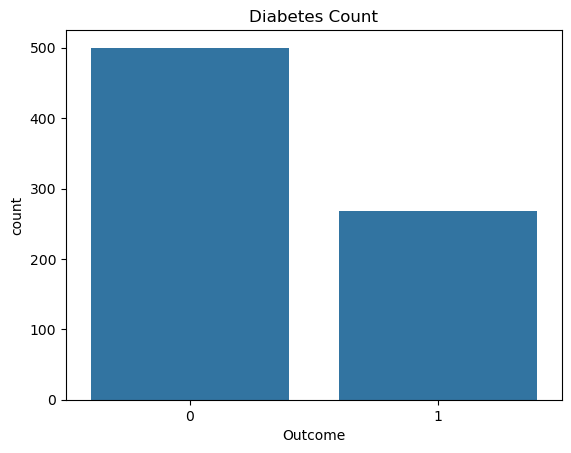

In [44]:
sns.countplot(x="Outcome", data=df1_copy)

plt.title("Diabetes Count")
plt.show()

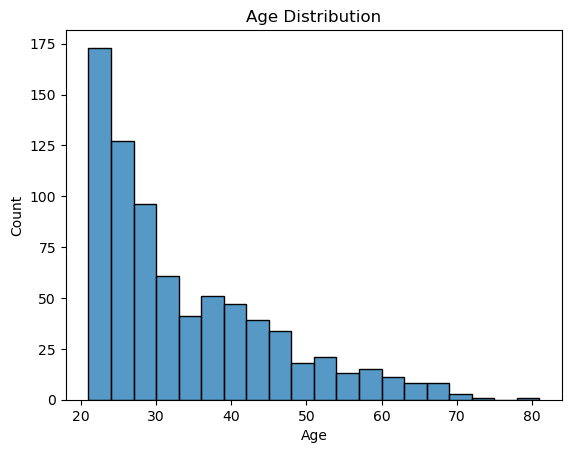

In [45]:
sns.histplot(df1_copy["Age"], bins=20)

plt.title("Age Distribution")
plt.show()

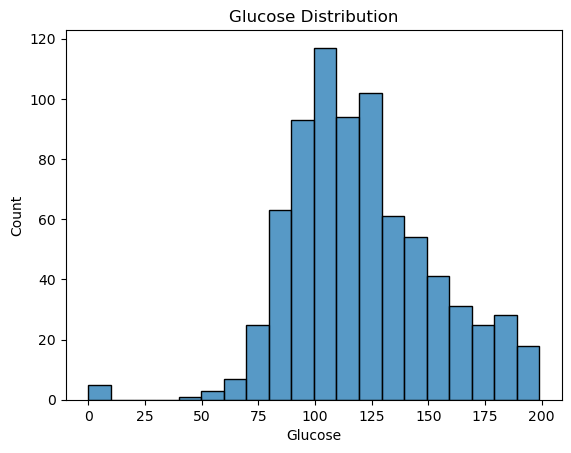

In [46]:
sns.histplot(df1_copy["Glucose"], bins=20)

plt.title("Glucose Distribution")
plt.show()

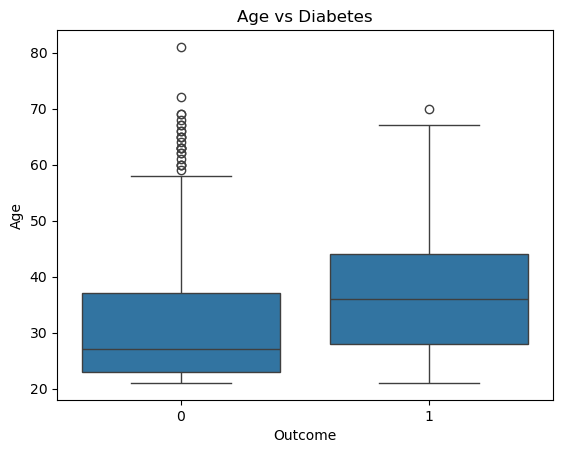

In [47]:
sns.boxplot(x="Outcome", y="Age", data=df1_copy)

plt.title("Age vs Diabetes")
plt.show()


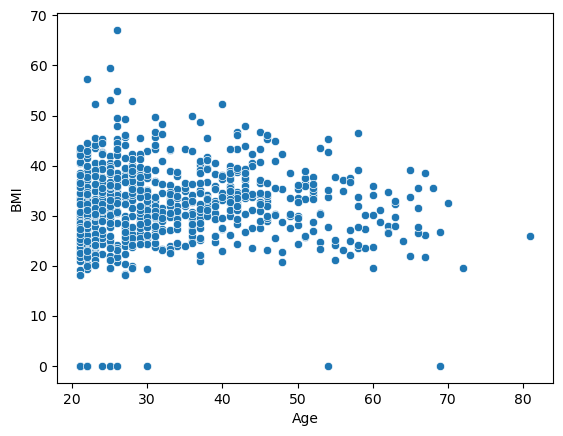

In [48]:
sns.scatterplot(x="Age", y="BMI", data=df1_copy)
plt.show()

<Axes: xlabel='Outcome', ylabel='Glucose'>

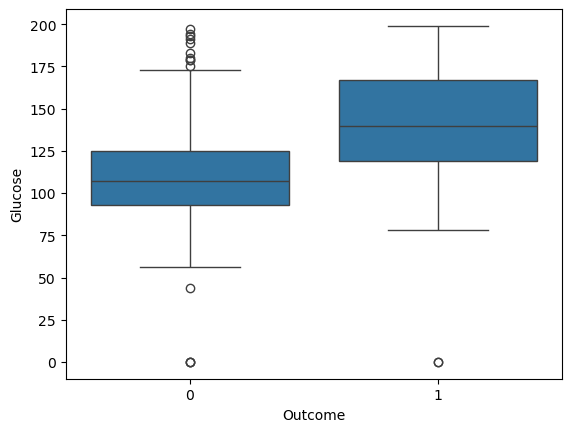

In [49]:
sns.boxplot(x="Outcome", y="Glucose", data=df1_copy)

In [51]:
df1_copy["AgeGroup"] = pd.cut(df1_copy["Age"],
                        bins=[20,30,40,50,60,80],
                        labels=["20s","30s","40s","50s","60+"])

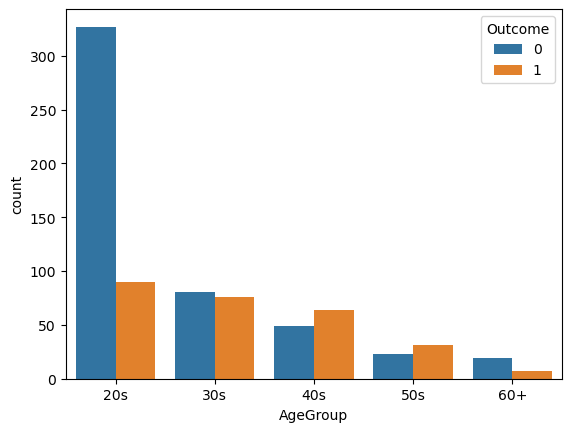

In [52]:
sns.countplot(x="AgeGroup", hue="Outcome", data=df1_copy)
plt.show()

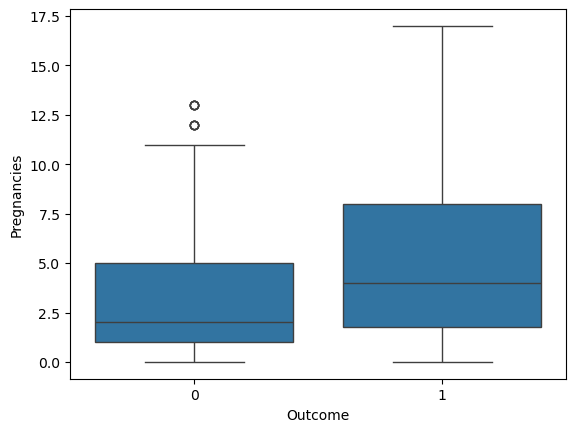

In [53]:
sns.boxplot(x="Outcome", y="Pregnancies", data=df1_copy)
plt.show()

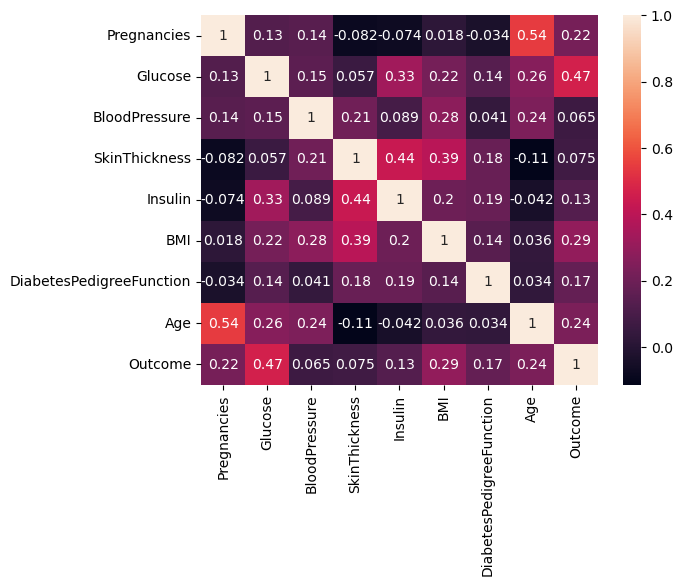

In [54]:
sns.heatmap(df1_copy.corr(numeric_only=True), annot=True)
plt.show()

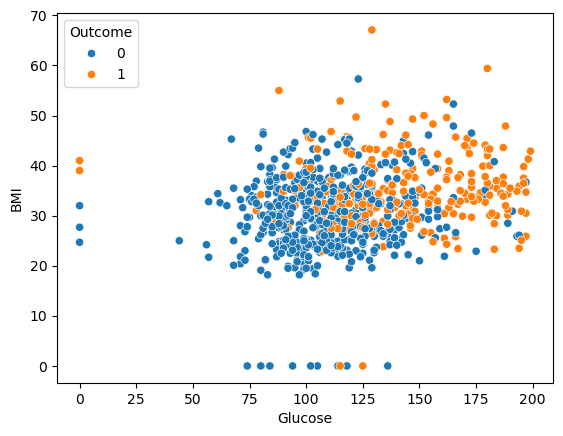

In [55]:
sns.scatterplot(x="Glucose", y="BMI", hue="Outcome", data=df1_copy)
plt.show()

In [ ]:
sns.pairplot(df1_copy, hue="Outcome")
plt.show()